# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [1]:
from Tools.DatasetTools.Commoms import *
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor

# options 

In [2]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' 'Fe-Mo'
case = 'POSCAR-initial'  # 'POSCAR-relaxed']
rescale_by_atoms = True #  False]
subcase = 'rescaled' #  'noscaled' ] 
Force = True
CuratedBS = os.path.join(dataset,'FurtherCuratedParsedBriefSummary.pkl')

In [3]:
components = dataset.replace('-','')

In [4]:
BS = pd.read_pickle(CuratedBS)

Features = Featurizer(BS)

chech that the chemistry resetting is correct!

# Sort Poscar files

In [5]:
searchs = 'POSCAR.initial'
files = get_file_paths(dataset, searchs)
atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
sublatticesortersfile = os.path.join(atomsobjectslocation, 'SORTERS.pkl')
sublatticetagfile = os.path.join(atomsobjectslocation, 'SUBLATICETAGS.pkl')

In [6]:
sublatticesortersfile

'Fe-Mo/Atomsobjects/SORTERS.pkl'

In [7]:
if not os.path.exists(sublatticesortersfile): # need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
    SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
    SORTERS.to_pickle(sublatticesortersfile)
    SUBLATICETAGS.to_pickle(sublatticetagfile)
else:
    SORTERS = pd.read_pickle(sublatticesortersfile)
    SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

# Now I have to pick the atoms objects

In [8]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
database = f'{dataset}/**/{case}'
AtomsFile = os.path.join(atomsobjectslocation,f'{components}-{case}-{subcase}-AtomsObjects.pkl')

In [9]:
if not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(database=database,rescale_by_atoms=True, reset_chemistry=True,file_filter = 'initial$')
    Atoms_Objects.to_pickle(AtomsFile)
    Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

In [10]:
Atoms_Objects.atoms.isna().sum()

0

In [11]:
allindex = Atoms_Objects.index.intersection(BS.index)

In [12]:
Atoms_Objects = Atoms_Objects.loc[allindex]

In [13]:
Atoms_Objects.to_pickle(AtomsFile)

In [14]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [15]:
difference = BS.index.difference(Atoms_Objects.index)

In [16]:
difference

Index([], dtype='object')

#  visualization of some structures

In [17]:
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [18]:
from ase.visualize.plot import plot_atoms

In [19]:
Atoms_Objects

,atoms,file
Fe_pv8Mo_sv22.sigma-BBABB.FM,"(Atom('Fe', [5.782198309088275, 2.810542212157...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/sigma-B...
Fe_pv10Mo_sv20.sigma-ABBAB.FM,"(Atom('Fe', [1.6342458921084402, 1.63424589210...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/sigma-A...
Fe_pv4Mo_sv20.C36-ABBBB.FM,"(Atom('Fe', [0.38944219439327715, -0.674533352...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/C36-ABB...
Fe_pv5Mo_sv24.chi-AABB.FM,"(Atom('Fe', [1.7698612066984885, 1.76986120669...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/chi-AAB...
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,"(Atom('Fe', [5.094816709933672, 4.654318760768...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/R-AAAAB...
...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,"(Atom('Fe', [-1.1429947349541574, 0.6599080102...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/mu-ABBB...
Fe_pv8Mo_sv22.sigma-BBABB.NM,"(Atom('Fe', [5.782198309088275, 2.810542212157...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/sigma-B...
Fe_pv1Mo_sv3.L12-AB3.FM,"(Atom('Fe', [0.0, 0.0, 0.0], index=0), Atom('M...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/L12-AB3...
Fe_pv8Mo_sv22.sigma-BBBBA.FM,"(Atom('Fe', [3.275982323724936, 3.275982323724...",[Fe-Mo/data/Fe_pv-Mo_sv/POSCAR-initial/sigma-B...


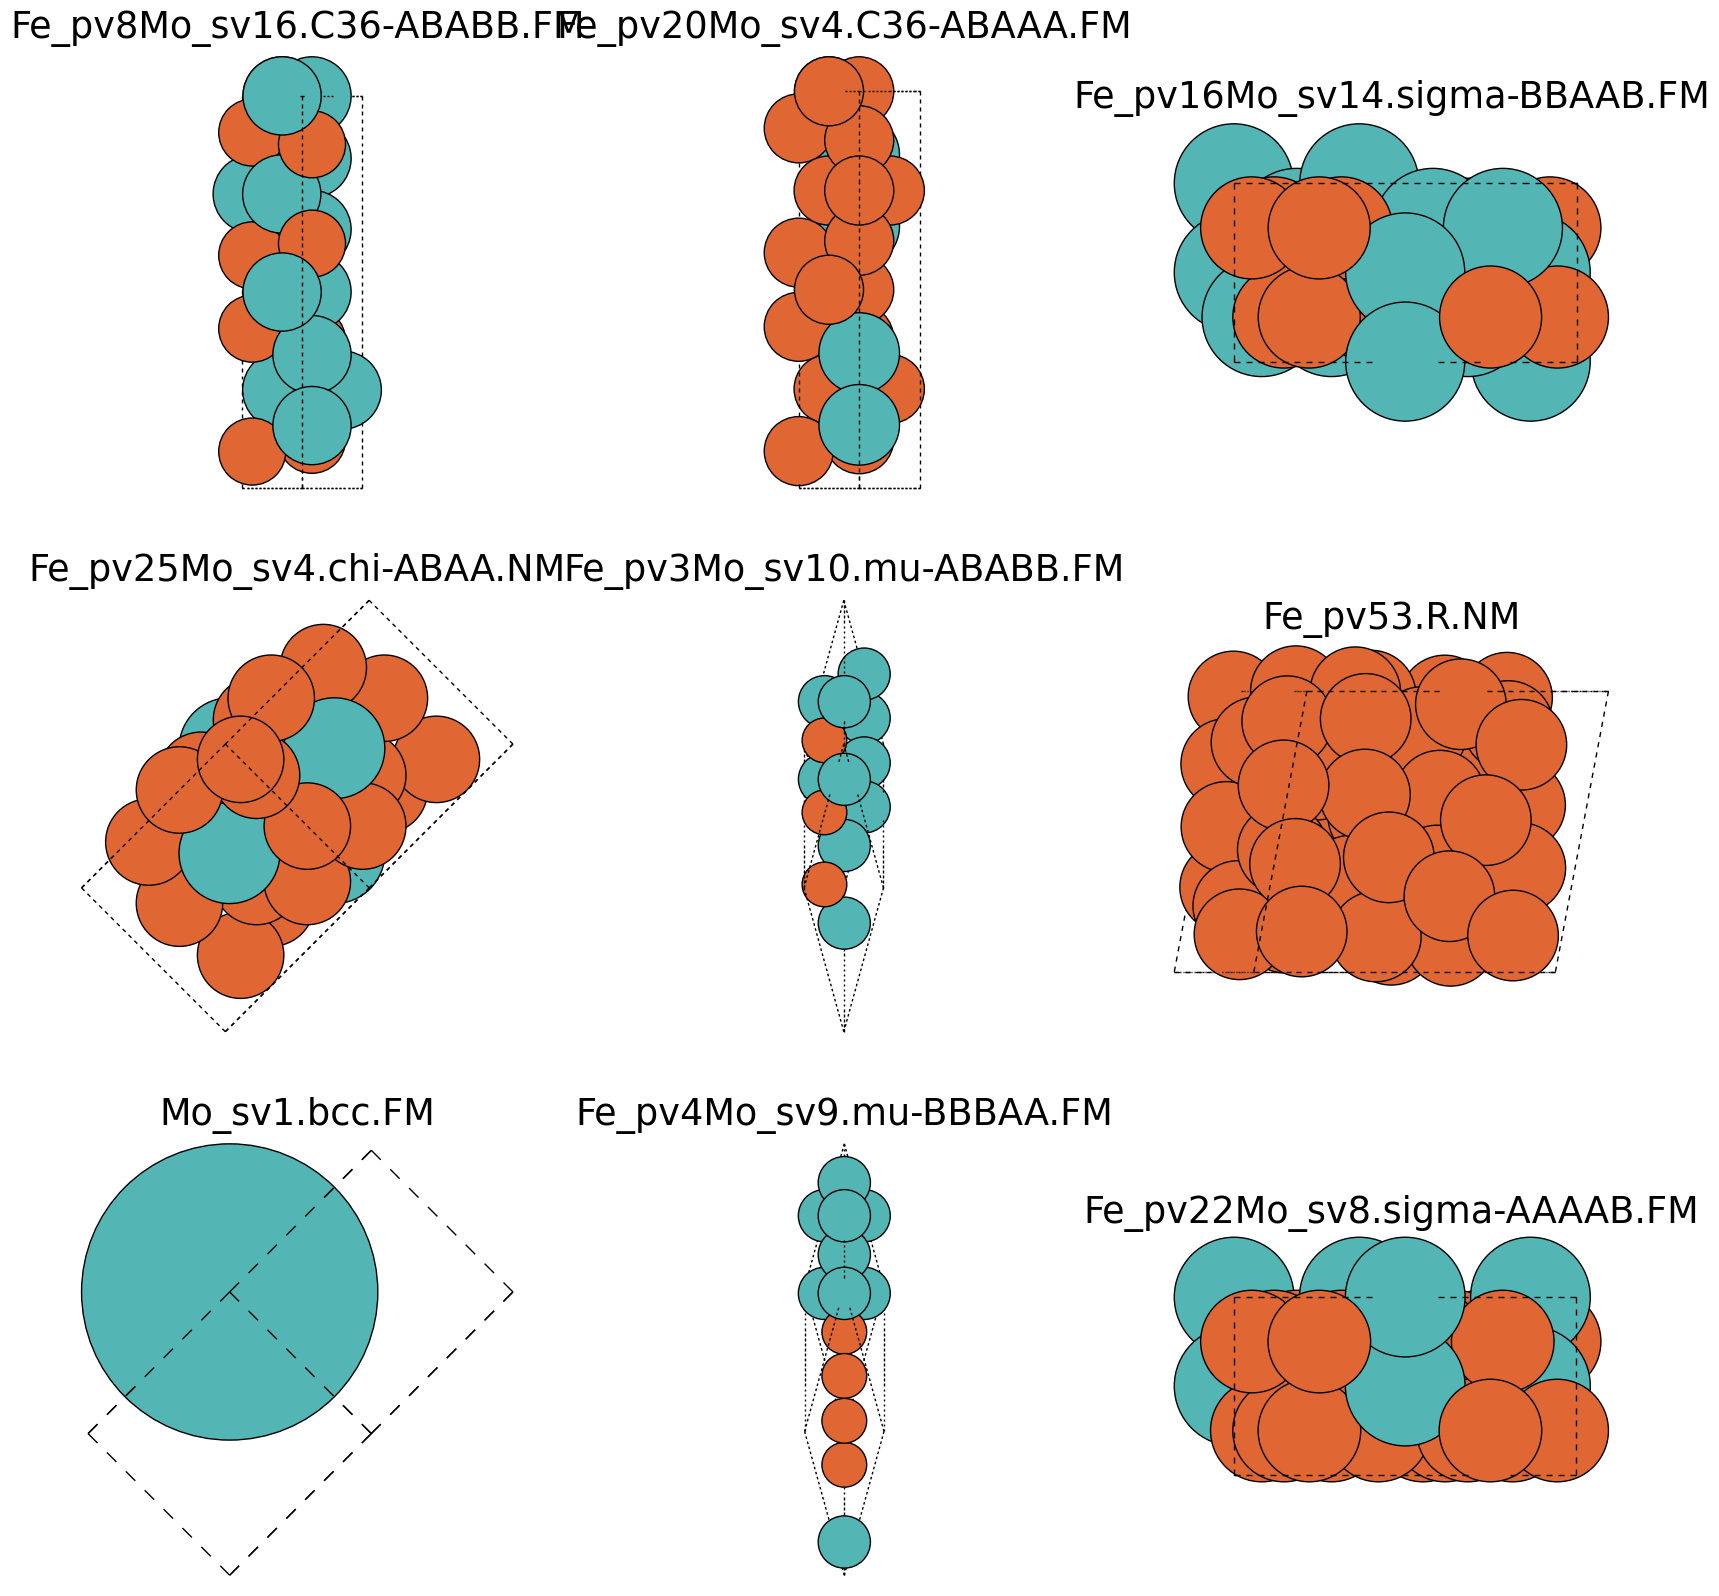

In [20]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [21]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

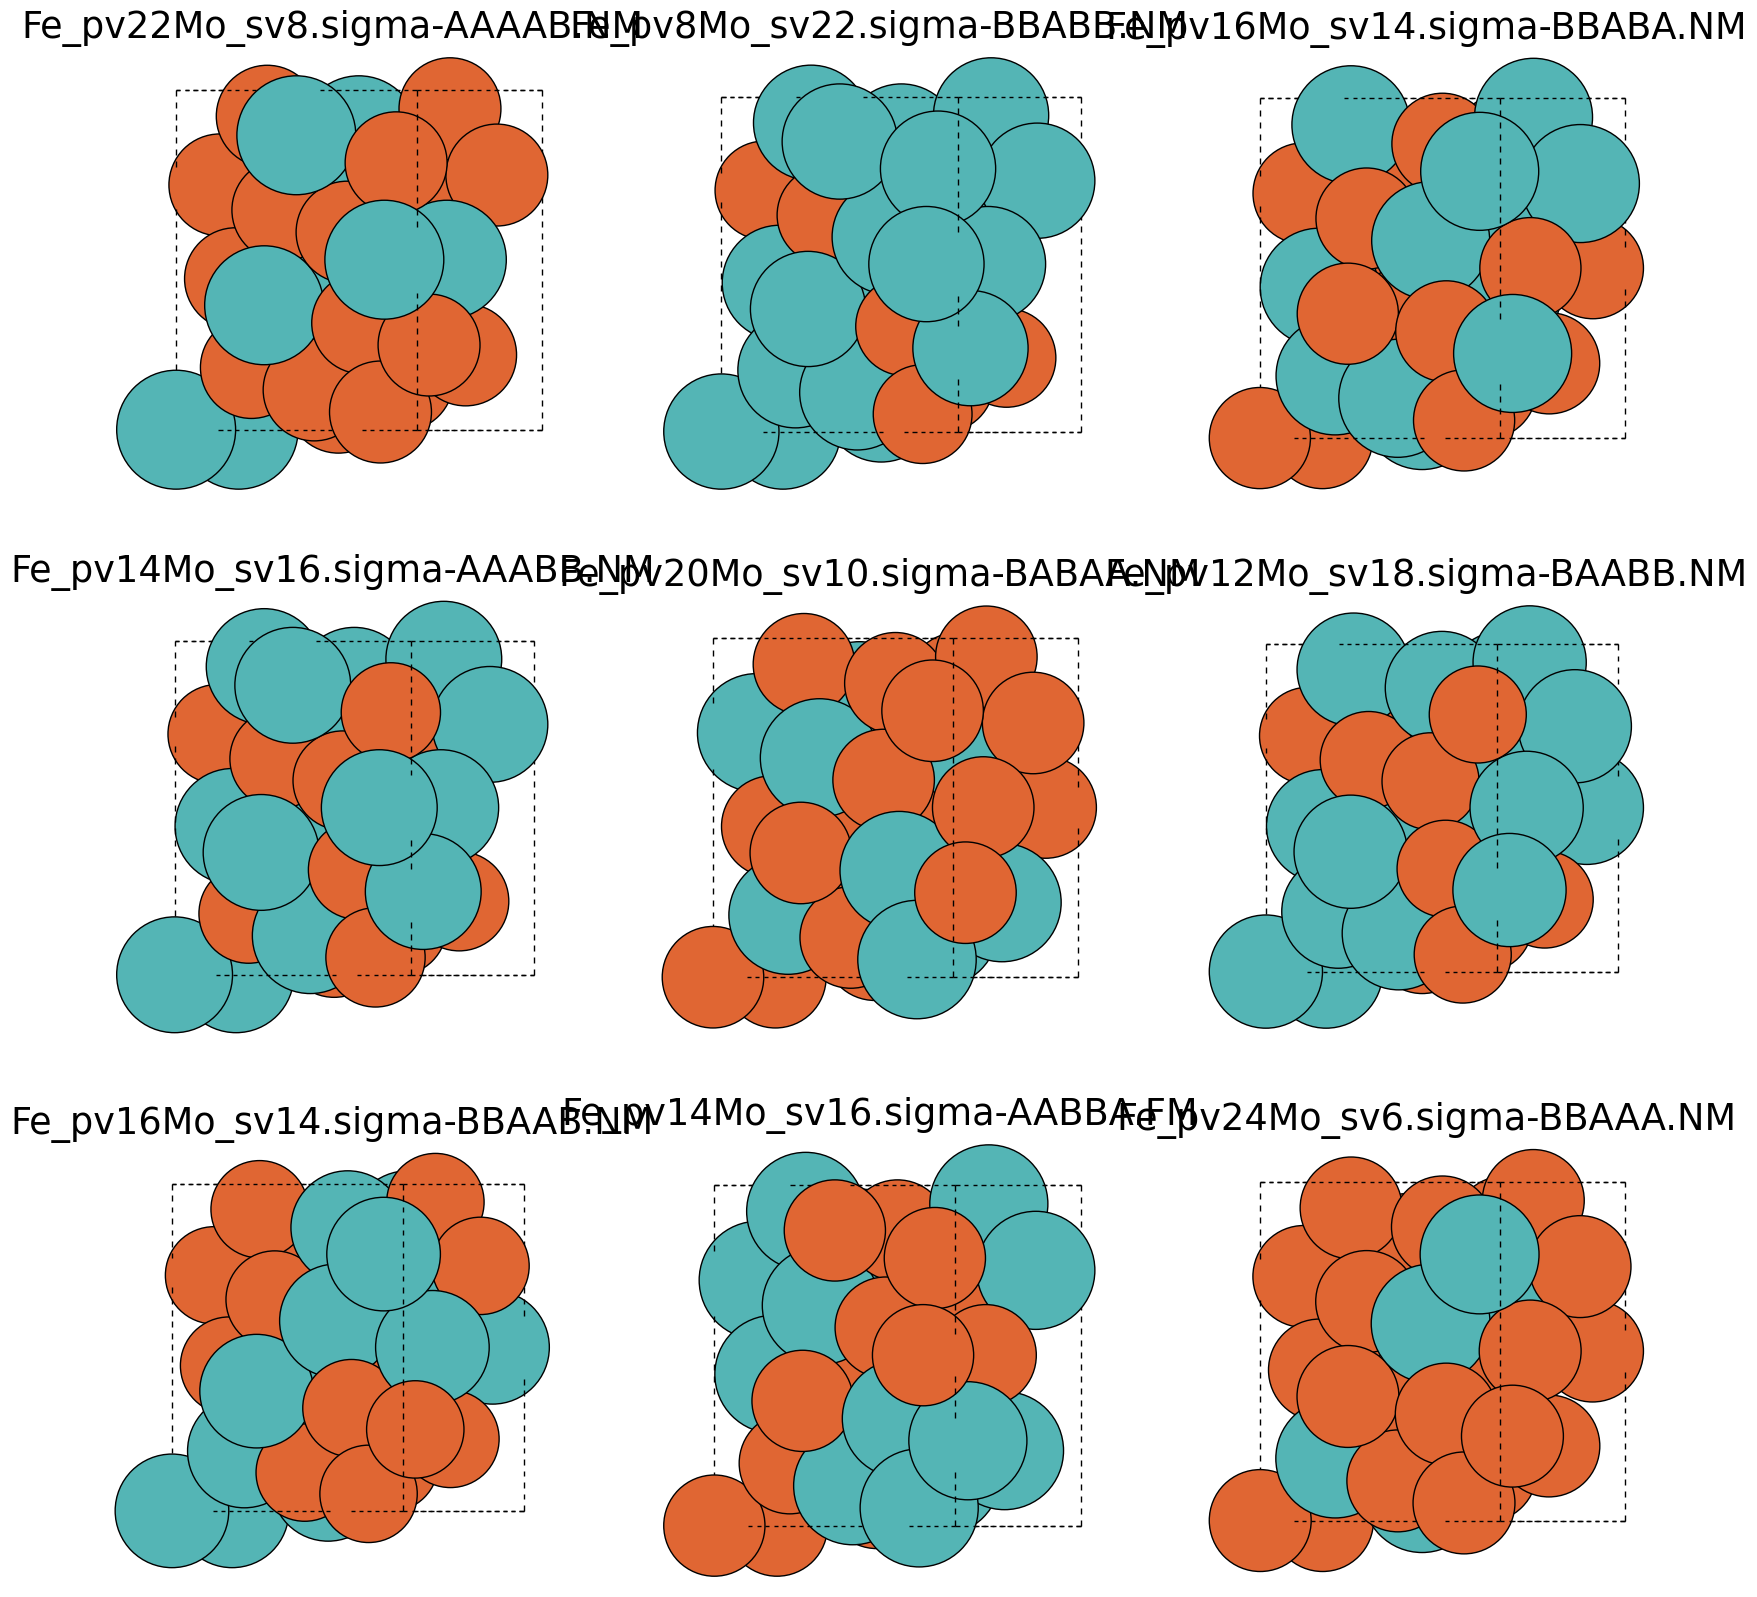

In [22]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [23]:
Problems = BS.index.difference(Atoms_Objects.index)

In [24]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase


In [25]:
GoodBS = BS.loc[Atoms_Objects.index]

In [26]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.215355,0.215355,0.215355,sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,10,20,30,0.333333,0.666667,0.034369,0.034369,0.034369,sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.479921,0.479921,0.479921,C36
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,5,24,29,0.172414,0.827586,0.457352,0.457352,0.457352,chi
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,15,38,53,0.283019,0.716981,0.134967,0.112588,0.155125,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,3,10,13,0.230769,0.769231,0.326354,0.308107,0.342791,mu
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.224750,0.203664,0.243743,sigma
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,1,3,4,0.250000,0.750000,0.278101,0.278101,0.278101,fcc
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.228782,0.228782,0.228782,sigma


In [27]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [28]:
GoodBS.to_pickle(FullyCuratedBSFile)

#  Final Distributions of targets

In [29]:
plt.rc('axes.spines', bottom=True, top=True, right=True, left=True)

<AxesSubplot:xlabel='B0', ylabel='Count'>

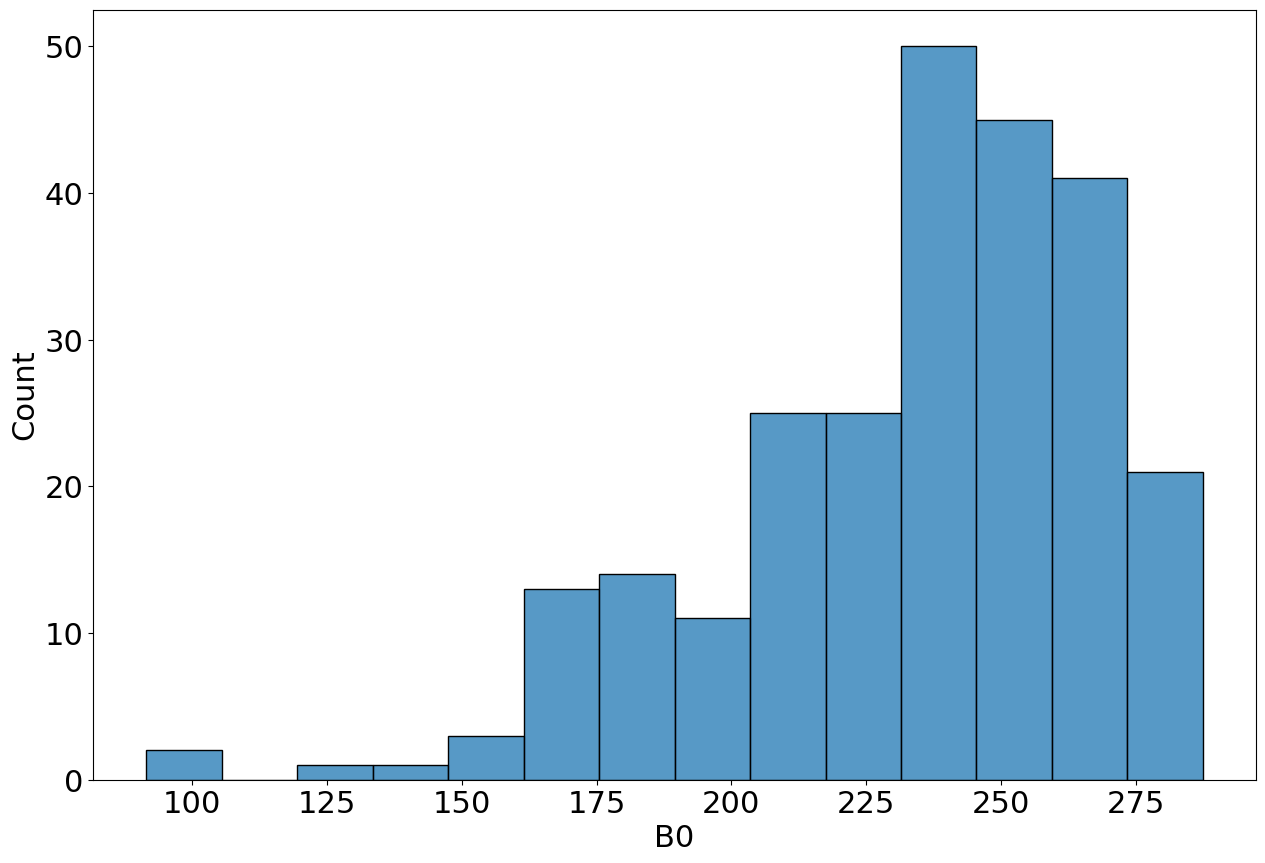

In [30]:
sns.histplot(BS['B0'])

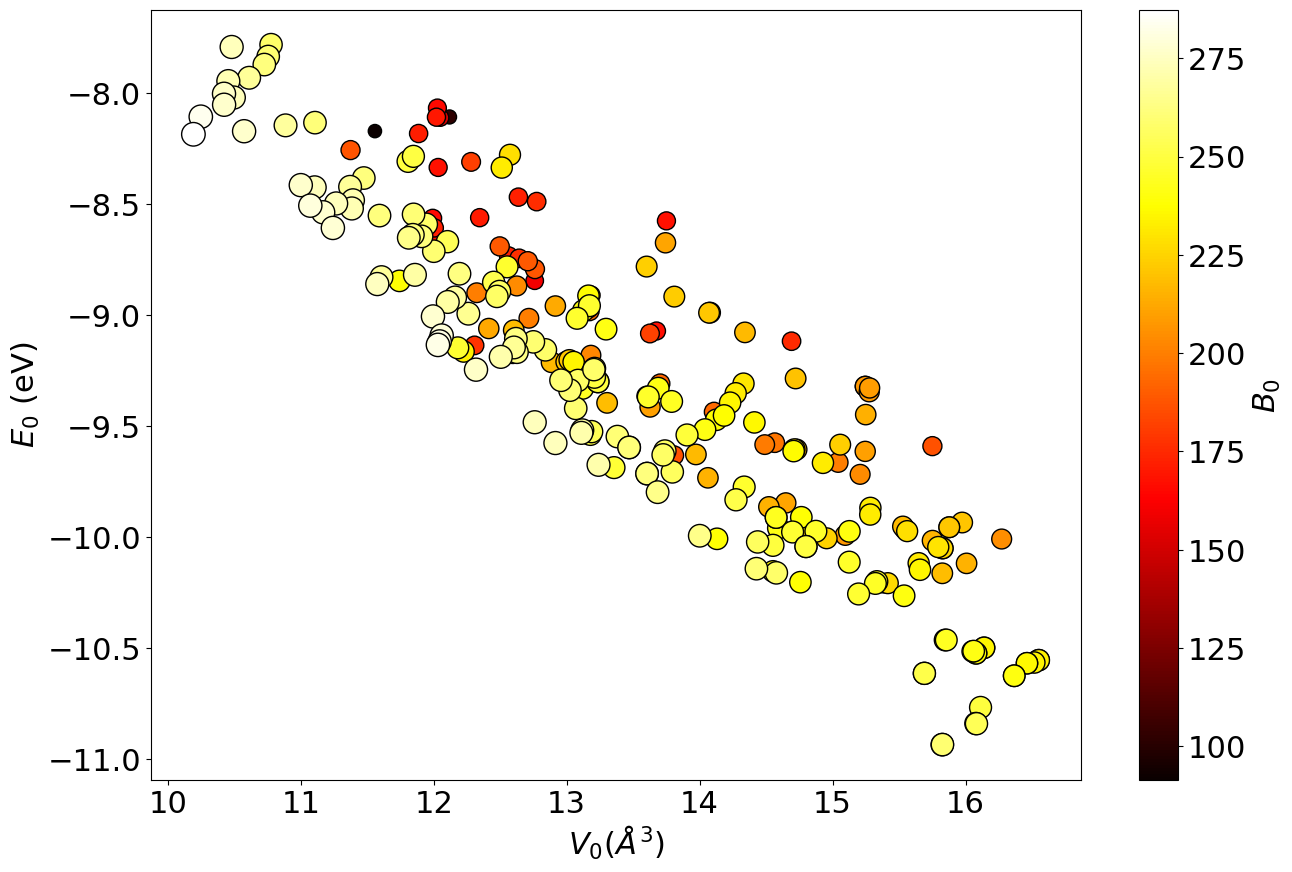

In [31]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(r'$E_0$ (eV)')
plt.xlabel(r'$V_0 (\AA^3)$')
cbar.set_label(r'$B_0$')
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )

In [32]:
volumes = Atoms_Objects['atoms'].map(lambda a: a.get_volume())/BS['num_atoms']

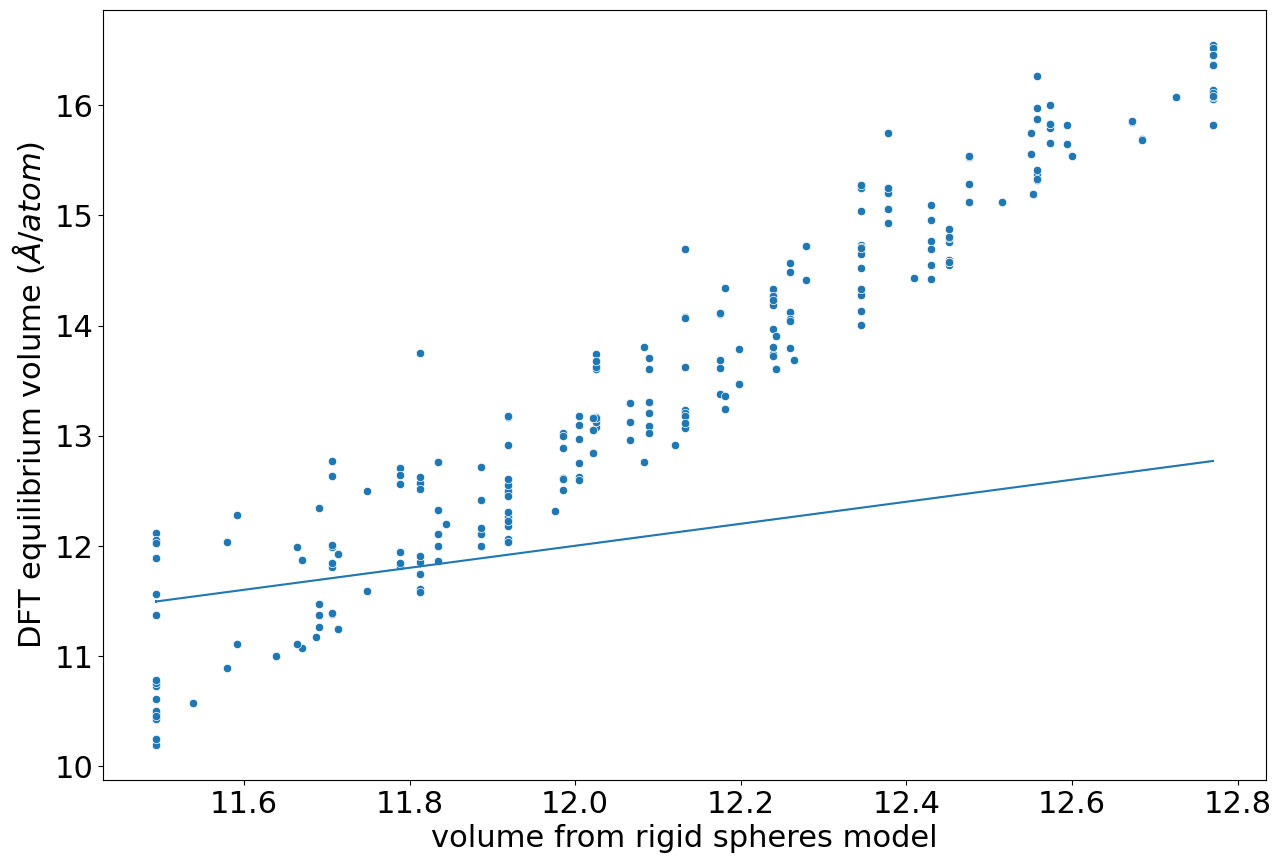

In [33]:
ax  = sns.scatterplot(volumes, BS['V0'])
ax = sns.lineplot(volumes, volumes, ax = ax)
ax.set_ylabel(r'DFT equilibrium volume ($ \AA /atom $)')
ax.set_xlabel('volume from rigid spheres model')
plt.ion()